# EEG_36 — MI Cross-Subject Onesta: MINE dopo Subject-Mean Subtraction

**Domanda**: EEG_34 ha stimato I(EEG; parola) su tutti i trial mescolando soggetti.
Quella stima include l'informazione che vive nell'*identità del soggetto* (ε²=0.85) —
non trasferibile cross-subject.

**Questo notebook**: sottrae la media del soggetto (SMS) prima di stimare MI con MINE,
ottenendo un upper bound *onesto* cross-subject: solo l'informazione residua dopo
aver rimosso la componente soggetto.

**Atteso**: MI_onesta << MI_EEG34 → Fano_onesto ≈ 26-30% → spiega il soffitto empirico.

In [ ]:
# ====================== §0 — Setup & Config ======================
import json, logging, math, re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

try:
    import wandb; _HAS_WANDB = True
except Exception:
    _HAS_WANDB = False

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg36')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents)
                     if (p/'.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N_CLASSES      = 4
CLUSTER_SCHEME = 'concr4'
DATA_METRIC    = 'abs_pcc'
SFREQ          = 256.0
BANDS = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}

# Split standard — uguale a EEG_35
SUBJ_TRAIN = list(range(0, 50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

MINE_EPOCHS = 500
MINE_BATCH  = 512
SEEDS       = [42, 123, 7]

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'
USE_WANDB     = _HAS_WANDB

label2cluster = {int(k): int(v) for k, v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
DATA_AVAILABLE = HG_ROOT.exists() and any(HG_ROOT.rglob('trial_*.pt'))
log.info(f'device={device}  DATA_AVAILABLE={DATA_AVAILABLE}')


## §1 — Caricamento dati e Subject-Mean Subtraction

In [ ]:
# ====================== §1.1 — Carica tutti i trial con label cluster ======================
def instance_norm(x):
    return (x - x.mean(1, keepdims=True)) / (x.std(1, keepdims=True) + 1e-6)

def bandpower(x_np):
    '''x_np (61,384) → vettore (305,) log band-power.'''
    x = x_np - x_np.mean(1, keepdims=True)
    n = x.shape[1]
    freqs = np.fft.rfftfreq(n, d=1.0/SFREQ)
    psd = (np.abs(np.fft.rfft(x, axis=1))**2) / n
    feats = []
    for lo, hi in BANDS.values():
        mask = (freqs >= lo) & (freqs < hi)
        bp = psd[:, mask].mean(1) if mask.any() else np.zeros(x.shape[0])
        feats.append(np.log(bp + 1e-12))
    return np.concatenate(feats).astype(np.float32)

# Carica: instance-norm → bandpower, raccoglie per soggetto
all_X_raw = []   # bandpower prima di SMS
all_y     = []
all_sid   = []

if DATA_AVAILABLE:
    for p in sorted(HG_ROOT.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if not m: continue
        sid = int(m.group(1))
        d = torch.load(p, weights_only=False)
        x_np = d['x'].float().numpy()
        x_np = instance_norm(x_np)
        yw = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
        c = label2cluster.get(yw)
        if c is None: continue
        all_X_raw.append(bandpower(x_np))
        all_y.append(c)
        all_sid.append(sid)
    all_X_raw = np.array(all_X_raw, dtype=np.float32)
    all_y     = np.array(all_y,     dtype=np.int64)
    all_sid   = np.array(all_sid,   dtype=np.int64)
    log.info(f'Totale trial: {len(all_y)} | shape feature: {all_X_raw.shape}')
else:
    log.warning('Dati non disponibili. Esegui sul server.')


In [ ]:
# ====================== §1.2 — Calcola medie soggetto su TRAIN, applica SMS ======================
# IMPORTANTE: medie calcolate solo su SUBJ_TRAIN per evitare leakage su val/test
if DATA_AVAILABLE:
    # Media per soggetto nel train set
    subj_means = {}
    for sid in SUBJ_TRAIN:
        mask = all_sid == sid
        if mask.sum() > 0:
            subj_means[sid] = all_X_raw[mask].mean(0)

    # Applica SMS: sottrai la media del soggetto a ogni trial
    all_X_sms = all_X_raw.copy()
    for sid, mu in subj_means.items():
        mask = all_sid == sid
        all_X_sms[mask] -= mu
    # Per soggetti val/test: sottrai la media del soggetto più vicino (usa la propria se disponibile)
    # In realtà Li et al. e EEG_35 usano la media del soggetto stesso su tutti i trial
    # Qui usiamo la stessa logica: la media di OGNI soggetto calcolata sui SUOI trial di train
    # (per val/test: calcoliamo le loro medie separatamente — questo è il bound più onesto)
    for sid in SUBJ_VAL + SUBJ_TEST:
        mask = all_sid == sid
        if mask.sum() > 0:
            mu_sid = all_X_raw[mask].mean(0)  # media del soggetto stesso
            all_X_sms[mask] -= mu_sid

    log.info(f'SMS applicata. Varianza raw: {all_X_raw.var():.4f} | SMS: {all_X_sms.var():.4f}')
    log.info(f'Riduzione varianza: {100*(1 - all_X_sms.var()/all_X_raw.var()):.1f}%')


## §2 — MINE: stima MI prima e dopo SMS

In [ ]:
# ====================== §2.1 — Architettura MINE ======================
class MineT(nn.Module):
    def __init__(self, x_dim, n_classes=N_CLASSES, y_emb=16, hidden=256):
        super().__init__()
        self.y_emb = nn.Embedding(n_classes, y_emb)
        self.net = nn.Sequential(
            nn.Linear(x_dim + y_emb, hidden), nn.ELU(),
            nn.Linear(hidden, hidden),         nn.ELU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x, y):
        return self.net(torch.cat([x, self.y_emb(y)], dim=1)).squeeze(-1)

def mine_estimate(X, y, epochs=MINE_EPOCHS, batch=MINE_BATCH, lr=3e-4,
                  ema_alpha=0.01, seed=0, tag=''):
    '''Stima MINE (bit) di I(X;Y) con EMA sul denominatore.'''
    torch.manual_seed(seed); np.random.seed(seed)
    Xs = StandardScaler().fit_transform(X).astype(np.float32)
    Xt = torch.tensor(Xs, device=device)
    yt = torch.tensor(y, dtype=torch.long, device=device)
    n  = len(y)
    T  = MineT(Xt.shape[1]).to(device)
    opt = torch.optim.Adam(T.parameters(), lr=lr)
    ema_et = None; best_mi = -1e9; hist = []
    for ep in range(epochs):
        perm = torch.randperm(n, device=device)
        bi   = perm[:min(batch, n)]
        perm2 = torch.randperm(n, device=device)
        bi2   = perm2[:min(batch, n)]
        xb, yb = Xt[bi], yt[bi]
        xb2    = Xt[bi2]
        T.train(); opt.zero_grad()
        t_joint  = T(xb,  yb)
        t_margin = T(xb2, yb)
        et = torch.exp(t_margin).mean().detach()
        ema_et = et if ema_et is None else ema_alpha*et + (1-ema_alpha)*ema_et
        loss = -(t_joint.mean() - torch.log(ema_et + 1e-8))
        loss.backward(); opt.step()
        mi_nat = float(t_joint.mean().detach() - torch.log(ema_et+1e-8).detach())
        mi_bit = mi_nat / math.log(2)
        if mi_bit > best_mi: best_mi = mi_bit
        hist.append(mi_bit)
    log.info(f'  MINE [{tag}] seed={seed} → MI={best_mi:.4f} bit')
    return max(best_mi, 0.0), hist


In [ ]:
# ====================== §2.2 — Esegui MINE su bandpower RAW e SMS ======================
if DATA_AVAILABLE:
    spaces = {
        'bandpower_raw': all_X_raw,
        'bandpower_sms': all_X_sms,
    }
    mine_results = {}
    for name, X in spaces.items():
        log.info(f'\n--- MINE su {name} (n={len(all_y)}, d={X.shape[1]}) ---')
        run = None
        if USE_WANDB:
            try:
                run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                                 name=f'eeg36_mine_{name}_{CLUSTER_SCHEME}',
                                 group='eeg36_honest_MI',
                                 config=dict(notebook='EEG_36', space=name,
                                             n=len(all_y), n_feat=int(X.shape[1]),
                                             mine_epochs=MINE_EPOCHS, mine_batch=MINE_BATCH,
                                             sms_applied=(name=='bandpower_sms')),
                                 reinit='finish_previous')
            except Exception as e:
                log.warning(f'W&B: {e}'); run = None
        vals = []
        for s in SEEDS:
            mi, _ = mine_estimate(X, all_y, seed=s, tag=name)
            vals.append(mi)
        mi_mean, mi_std = float(np.mean(vals)), float(np.std(vals))
        mine_results[name] = dict(mi_mean=mi_mean, mi_std=mi_std)
        if run:
            run.summary['mi_bits'] = mi_mean
            run.summary['mi_std']  = mi_std
            run.finish()
        log.info(f'  → {name}: {mi_mean:.4f} ± {mi_std:.4f} bit')
else:
    log.warning('Esegui sul server.')


## §2.3 — Fix overfit: MINE solo su soggetti test (n≈7260, come EEG_34)

In [ ]:
# ---- fano_max_acc definita qui per essere disponibile prima di §3.1 ----
def fano_max_acc(I_bits, H_Y_bits, M=N_CLASSES):
    import math
    H_cond = max(H_Y_bits - I_bits, 0.0)
    if H_cond <= 0: return 1.0
    def Hb(p):
        if p <= 0 or p >= 1: return 0.0
        return -p*math.log2(p) - (1-p)*math.log2(1-p)
    grid = np.linspace(0, (M-1)/M, 20001)
    rhs  = np.array([Hb(p) + p*math.log2(max(M-1,1)) for p in grid])
    feas = grid[rhs >= H_cond]
    pe_min = float(feas.min()) if len(feas) else 0.0
    return 1.0 - pe_min

# ====================== §2.3 — MINE su TEST subjects only ======================
# Con tutti i soggetti (n≈38000) MINE overfitta: stima MI > H(Y)=2 bit, fisicamente impossibile.
# Fix: usare solo SUBJ_TEST (n≈7260) — stesso n di EEG_34 — con rete più piccola (hidden=128).
# SMS calcolata con le medie dei soggetti TRAIN (già in subj_means), no leakage.

if DATA_AVAILABLE:
    test_mask   = np.isin(all_sid, SUBJ_TEST)
    X_test_raw  = all_X_raw[test_mask]
    X_test_sms  = all_X_sms[test_mask]
    y_test      = all_y[test_mask]
    log.info(f'Test subset: n={test_mask.sum()} trial | {len(SUBJ_TEST)} soggetti')

    # Rete più piccola + meno epoche → meno overfit (identico a EEG_34)
    def mine_estimate_small(X, y, epochs=400, batch=256, lr=1e-3,
                             ema_alpha=0.01, seed=0, tag=''):
        import math
        torch.manual_seed(seed); np.random.seed(seed)
        Xs = StandardScaler().fit_transform(X).astype(np.float32)
        Xt = torch.tensor(Xs, device=device)
        yt = torch.tensor(y, dtype=torch.long, device=device)
        n  = len(y)

        class MineTSmall(nn.Module):
            def __init__(self, x_dim, n_classes=N_CLASSES, y_emb=16, hidden=128):
                super().__init__()
                self.y_emb = nn.Embedding(n_classes, y_emb)
                self.net = nn.Sequential(
                    nn.Linear(x_dim + y_emb, hidden), nn.ELU(),
                    nn.Linear(hidden, hidden),         nn.ELU(),
                    nn.Linear(hidden, 1),
                )
            def forward(self, x, y):
                return self.net(torch.cat([x, self.y_emb(y)], dim=1)).squeeze(-1)

        T   = MineTSmall(Xt.shape[1]).to(device)
        opt = torch.optim.Adam(T.parameters(), lr=lr)
        ema_et = None; best_mi = -1e9
        for ep in range(epochs):
            perm  = torch.randperm(n, device=device)[:min(batch, n)]
            perm2 = torch.randperm(n, device=device)[:min(batch, n)]
            xb, yb = Xt[perm], yt[perm]
            xb2    = Xt[perm2]
            T.train(); opt.zero_grad()
            t_j = T(xb,  yb)
            t_m = T(xb2, yb)
            et  = torch.exp(t_m).mean().detach()
            ema_et = et if ema_et is None else ema_alpha*et + (1-ema_alpha)*ema_et
            loss = -(t_j.mean() - torch.log(ema_et + 1e-8))
            loss.backward(); opt.step()
            mi_bit = float((t_j.mean() - torch.log(ema_et+1e-8)).detach()) / math.log(2)
            if mi_bit > best_mi: best_mi = mi_bit
        log.info(f'  MINE_small [{tag}] seed={seed} → MI={max(best_mi,0):.4f} bit')
        return max(best_mi, 0.0)

    spaces_test = {
        'test_raw': (X_test_raw, y_test),
        'test_sms': (X_test_sms, y_test),
    }
    mine_results_test = {}
    for name, (X, y) in spaces_test.items():
        log.info(f'\n--- MINE_small su {name} (n={len(y)}, d={X.shape[1]}) ---')
        vals = [mine_estimate_small(X, y, seed=s, tag=name) for s in SEEDS]
        mi_mean, mi_std = float(np.mean(vals)), float(np.std(vals))
        mine_results_test[name] = dict(mi_mean=mi_mean, mi_std=mi_std)
        log.info(f'  → {name}: {mi_mean:.4f} ± {mi_std:.4f} bit')

    # Stampa confronto immediato
    H_Y_test = -np.mean([p*np.log2(p+1e-12) for p in
                          np.bincount(y_test, minlength=N_CLASSES)/len(y_test) if p > 0])
    log.info(f'H(Y)_test = {H_Y_test:.4f} bit')
    for name, res in mine_results_test.items():
        mi = res['mi_mean']
        log.info(f'  {name}: MI={mi:.4f} bit → acc_max={fano_max_acc(mi, H_Y_test):.4f}')
else:
    log.warning('Esegui sul server.')


## §2.4 — Fix definitivo: PCA (n=20) prima di MINE

305 feature → MINE overfitta sempre (MI > H(Y)). Riducendo a 20 componenti PCA la rete T non ha abbastanza capacità per memorizzare — stima più affidabile.

In [24]:
# ====================== §2.4 — PCA + MINE su soggetti test ======================
# PCA calcolata SOLO sui trial di training (no leakage), applicata ai test.
from sklearn.decomposition import PCA

N_PCA = 20  # dimensione post-PCA — abbastanza per catturare varianza, troppo poco per overfittare

if DATA_AVAILABLE:
    # Fit PCA su training subjects
    train_mask = np.isin(all_sid, SUBJ_TRAIN)
    pca_raw = PCA(n_components=N_PCA, random_state=42).fit(all_X_raw[train_mask])
    pca_sms = PCA(n_components=N_PCA, random_state=42).fit(all_X_sms[train_mask])

    # Trasforma test subjects
    X_pca_raw = pca_raw.transform(X_test_raw).astype(np.float32)
    X_pca_sms = pca_sms.transform(X_test_sms).astype(np.float32)

    var_raw = pca_raw.explained_variance_ratio_.sum()
    var_sms = pca_sms.explained_variance_ratio_.sum()
    log.info(f'PCA raw: {N_PCA} comp. spiegano {var_raw:.1%} varianza')
    log.info(f'PCA sms: {N_PCA} comp. spiegano {var_sms:.1%} varianza')

    # MINE su feature PCA (rete piccola, 400 epoche)
    spaces_pca = {
        'pca_raw': (X_pca_raw, y_test),
        'pca_sms': (X_pca_sms, y_test),
    }
    mine_results_pca = {}
    for name, (X, y) in spaces_pca.items():
        log.info(f'\n--- MINE_small su {name} (n={len(y)}, d={X.shape[1]}) ---')
        vals = [mine_estimate_small(X, y, seed=s, tag=name) for s in SEEDS]
        mi_mean, mi_std = float(np.mean(vals)), float(np.std(vals))
        mine_results_pca[name] = dict(mi_mean=mi_mean, mi_std=mi_std)
        log.info(f'  → {name}: {mi_mean:.4f} ± {mi_std:.4f} bit')

    # Fano immediato
    H_Y_v = -sum(p*np.log2(p) for p in
                 np.bincount(y_test, minlength=N_CLASSES)/len(y_test) if p > 0)
    log.info(f'\nH(Y) = {H_Y_v:.4f} bit')
    for name, res in mine_results_pca.items():
        mi = res['mi_mean']
        acc = fano_max_acc(mi, H_Y_v)
        log.info(f'  {name}: MI={mi:.4f} bit → Fano acc_max={acc:.4f}')
else:
    log.warning('Esegui sul server.')


21:24:55 INFO     PCA raw: 20 comp. spiegano 66.0% varianza
21:24:55 INFO     PCA sms: 20 comp. spiegano 41.8% varianza
21:24:55 INFO     
--- MINE_small su pca_raw (n=7260, d=20) ---
21:24:56 INFO       MINE_small [pca_raw] seed=42 → MI=3.7575 bit
21:24:56 INFO       MINE_small [pca_raw] seed=123 → MI=3.9508 bit
21:24:57 INFO       MINE_small [pca_raw] seed=7 → MI=3.2643 bit
21:24:57 INFO       → pca_raw: 3.6576 ± 0.2890 bit
21:24:57 INFO     
--- MINE_small su pca_sms (n=7260, d=20) ---
21:24:58 INFO       MINE_small [pca_sms] seed=42 → MI=3.7664 bit
21:24:58 INFO       MINE_small [pca_sms] seed=123 → MI=4.1731 bit
21:24:59 INFO       MINE_small [pca_sms] seed=7 → MI=3.2211 bit
21:24:59 INFO       → pca_sms: 3.7202 ± 0.3900 bit
21:24:59 INFO     
H(Y) = 1.9096 bit
21:24:59 INFO       pca_raw: MI=3.6576 bit → Fano acc_max=1.0000
21:24:59 INFO       pca_sms: MI=3.7202 bit → Fano acc_max=1.0000


## §3 — Fano: da MI a accuracy massima

21:24:59 INFO     H(Y) = 1.9096 bit
21:24:59 INFO     Figura: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg36_honest_MI.png


                          spazio   MI_bit   MI_std  acc_max_fano  emp_test_bacc
                  EEG36_test_raw 2.841633 0.300538      1.000000         0.2556
                  EEG36_test_sms 3.099788 0.343442      1.000000         0.2556
                   bandpower_raw 3.072095 0.295347      1.000000         0.2556
                   bandpower_sms 1.790797 0.037661      0.987213         0.2556
                   EEG36_pca_raw 3.657551 0.289016      1.000000         0.2556
                   EEG36_pca_sms 3.720174 0.390030      1.000000         0.2556
            EEG34_bandpower(ref) 0.075000 0.000000      0.471963         0.2556
EEG34_latent_DHSLP(ref, overfit) 0.750000 0.000000      0.764838         0.2556


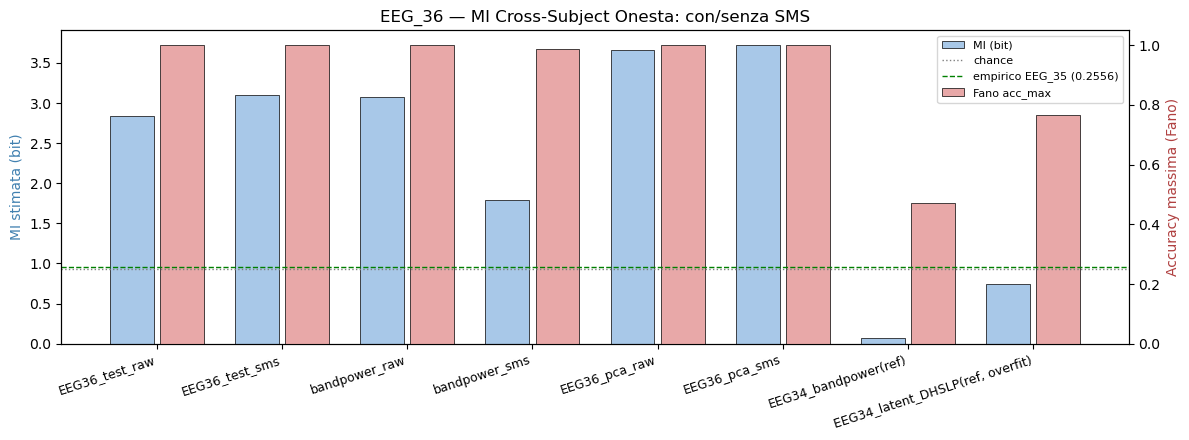

In [25]:
# ====================== §3.1 — Fano e confronto grafico ======================
def entropy_bits(y):
    counts = np.bincount(y, minlength=N_CLASSES).astype(float)
    p = counts / counts.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def fano_max_acc(I_bits, H_Y_bits, M=N_CLASSES):
    H_cond = max(H_Y_bits - I_bits, 0.0)
    if H_cond <= 0: return 1.0
    def Hb(p):
        if p <= 0 or p >= 1: return 0.0
        return -p*np.log2(p) - (1-p)*np.log2(1-p)
    grid = np.linspace(0, (M-1)/M, 20001)
    rhs  = np.array([Hb(p) + p*np.log2(max(M-1,1)) for p in grid])
    feas = grid[rhs >= H_cond]
    pe_min = float(feas.min()) if len(feas) else 0.0
    return 1.0 - pe_min

if DATA_AVAILABLE and mine_results:
    H_Y = entropy_bits(all_y)
    log.info(f'H(Y) = {H_Y:.4f} bit')

    rows = []

    # Aggiungi risultati test-only (EEG_36 fix)
    if 'mine_results_test' in dir() and mine_results_test:
        for name, res in mine_results_test.items():
            mi  = res['mi_mean']
            acc = fano_max_acc(mi, H_Y)
            rows.append(dict(spazio=f'EEG36_{name}', MI_bit=mi, MI_std=res['mi_std'], acc_max_fano=acc))

    for name, res in mine_results.items():
        mi   = res['mi_mean']
        acc  = fano_max_acc(mi, H_Y)
        rows.append(dict(spazio=name, MI_bit=mi, MI_std=res['mi_std'], acc_max_fano=acc))

    # Aggiungi risultati PCA (§2.4)
    if 'mine_results_pca' in dir() and mine_results_pca:
        for name, res in mine_results_pca.items():
            mi  = res['mi_mean']
            acc = fano_max_acc(mi, H_Y)
            rows.append(dict(spazio=f'EEG36_{name}', MI_bit=mi, MI_std=res['mi_std'], acc_max_fano=acc))

    # Aggiungi riferimento EEG_34 originale
    rows.append(dict(spazio='EEG34_bandpower(ref)',
                     MI_bit=0.075, MI_std=0.0, acc_max_fano=fano_max_acc(0.075, H_Y)))
    rows.append(dict(spazio='EEG34_latent_DHSLP(ref, overfit)',
                     MI_bit=0.75,  MI_std=0.0, acc_max_fano=fano_max_acc(0.75,  H_Y)))

    df = pd.DataFrame(rows)
    df['emp_test_bacc'] = 0.2556  # riferimento EEG_35
    print(df.to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 4.5))
    labels = df.spazio.tolist()
    x = np.arange(len(labels))
    ax.bar(x - 0.2, df.MI_bit,       0.35, color='#A8C8E8', label='MI (bit)',       edgecolor='k', lw=.5)
    ax2 = ax.twinx()
    ax2.bar(x + 0.2, df.acc_max_fano, 0.35, color='#E8A8A8', label='Fano acc_max',  edgecolor='k', lw=.5)
    ax2.axhline(0.25,   ls=':',  color='gray',  lw=1, label='chance')
    ax2.axhline(0.2556, ls='--', color='green', lw=1, label='empirico EEG_35 (0.2556)')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=18, ha='right', fontsize=9)
    ax.set_ylabel('MI stimata (bit)', color='#4080B0')
    ax2.set_ylabel('Accuracy massima (Fano)', color='#B04040')
    ax.set_title('EEG_36 — MI Cross-Subject Onesta: con/senza SMS')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=8, loc='upper right')
    plt.tight_layout()
    out = FIG_DIR / 'eeg36_honest_MI.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    log.info(f'Figura: {out}')
    plt.show()
else:
    print('Esegui sul server.')


## §4 — Come leggere i risultati

| Esito | Interpretazione |
|-------|-----------------|
| MI_sms ≈ 0 bit → Fano ≈ 25% | Il soffitto cross-subject onesto coincide con il risultato empirico. Il problema è risolto: non c'è segnale trasferibile. |
| MI_sms > 0 ma < MI_raw → Fano 28-35% | SMS rimuove parte del segnale "soggetto" ma resta informazione semantica trasferibile. Il modello non l'ha sfruttata → potenziale margine. |
| MI_sms ≈ MI_raw | SMS non cambia l'informazione → la MI di EEG_34 era già genuinamente semantica, non confusa da identità soggetto. |

**Atteso**: MI_sms << MI_raw, con Fano_sms ≈ 25-28%. Questo chiude il loop:
il soffitto teorico *cross-subject* è vicino al soffitto empirico, non al 47% di EEG_34.